In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()


In [ ]:
X = housing.data
y = housing.target

In [ ]:
print(housing.feature_names)
print(X.shape)
print(y.shape)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
(20640, 8)
(20640,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


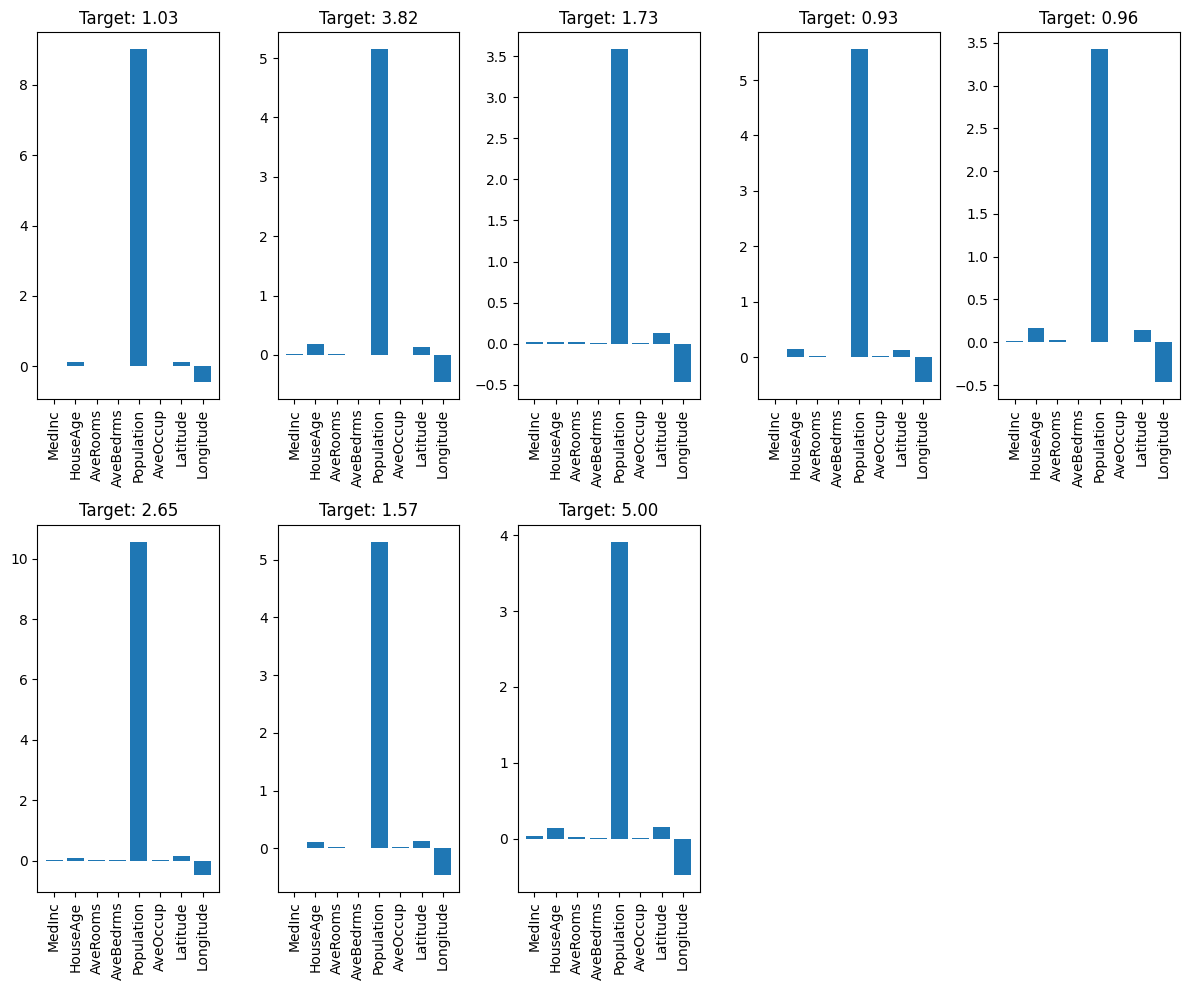

In [ ]:
plt.figure(figsize=(12,10))
for i in range (8):
  plt.subplot(2,5,i+1)
  plt.bar(housing.feature_names, X_train[i])
  plt.xticks(rotation=90)
  plt.title(f'Target: {y_train[i]:.2f}')
  plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu',input_shape=(8,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

In [ ]:
history = model.fit(X_train,y_train,epochs=20,batch_size=23,validation_split=0.2)
print(history.history.keys())

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 76.0381 - mean_absolute_error: 2.8112 - val_loss: 1.7065 - val_mean_absolute_error: 0.9935
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.8649 - mean_absolute_error: 1.7682 - val_loss: 36.7915 - val_mean_absolute_error: 4.6051
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 33.3224 - mean_absolute_error: 2.9806 - val_loss: 0.9753 - val_mean_absolute_error: 0.7469
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5191 - mean_absolute_error: 0.8862 - val_loss: 14.3574 - val_mean_absolute_error: 2.8236
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.8940 - mean_absolute_error: 0.9938 - val_loss: 1.2460 - val_mean_absolute_error: 0.7911
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17.5589 - mean_absolute_error: 2.0800 - val_loss: 0.9917 - val_mean_absolute_error: 0.6973
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5303 - mean_absolute_error: 1.174

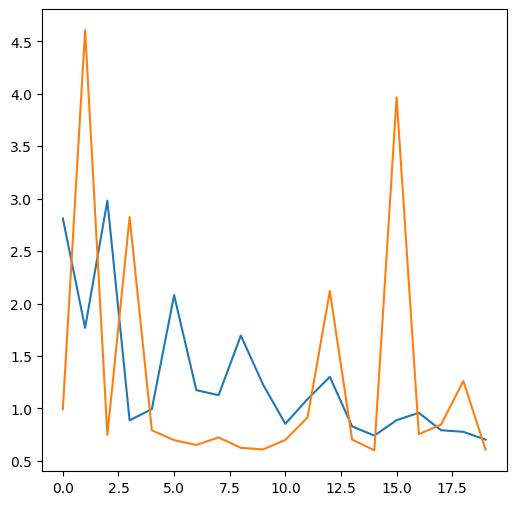

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(history.history['mean_absolute_error'],label='training accuracy')
plt.plot(history.history['val_mean_absolute_error'],label='validation accuracy')
plt.show()

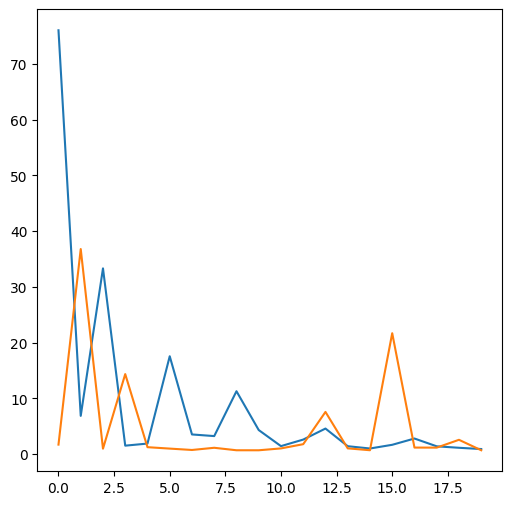

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(history.history['loss'],label='training accuracy')
plt.plot(history.history['val_loss'],label='validation accuracy')
plt.show()

In [ ]:
predictions = model.predict(X_test)
predicted_value = predictions[0][0]
print("Predicted Value:", predicted_value)
print("Actual Value:", y_test[0])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted Value: 0.97385824
Actual Value: 0.477


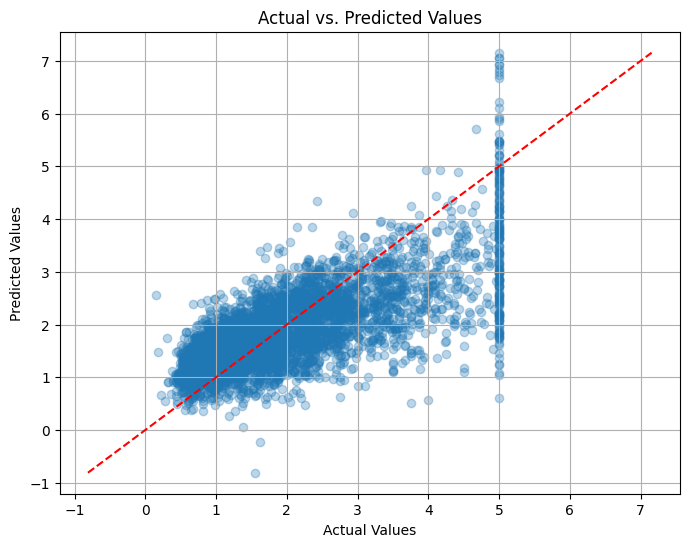

In [ ]:
predictions_1d = predictions.flatten()

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions_1d, alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
min_val = min(y_test.min(), predictions_1d.min())
max_val = max(y_test.max(), predictions_1d.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.grid(True)
plt.show()